<a href="https://colab.research.google.com/github/devaki-turimella/Future_ML_02/blob/main/support_ticket_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
# Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLP stuff
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# ML stuff
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [39]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/dev/customer support ticket dataset.csv')

print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Shape of dataset: (8469, 17)

Column names:
['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


In [5]:
# Look at first few rows
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,22-03-2021,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,01-06-2023 12:15,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,22-05-2021,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,01-06-2023 16:45,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,14-07-2020,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,01-06-2023 11:14,01-06-2023 18:05,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,13-11-2020,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,01-06-2023 07:29,01-06-2023 01:57,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,04-02-2020,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,01-06-2023 00:12,01-06-2023 19:53,1.0


In [40]:
# Basic info about the dataset
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   ob

In [41]:
# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64


In [42]:
# What ticket types do we have?
print("Ticket Types:")
print(df['Ticket Type'].value_counts())

print("\nTicket Priorities:")
print(df['Ticket Priority'].value_counts())

Ticket Types:
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

Ticket Priorities:
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64


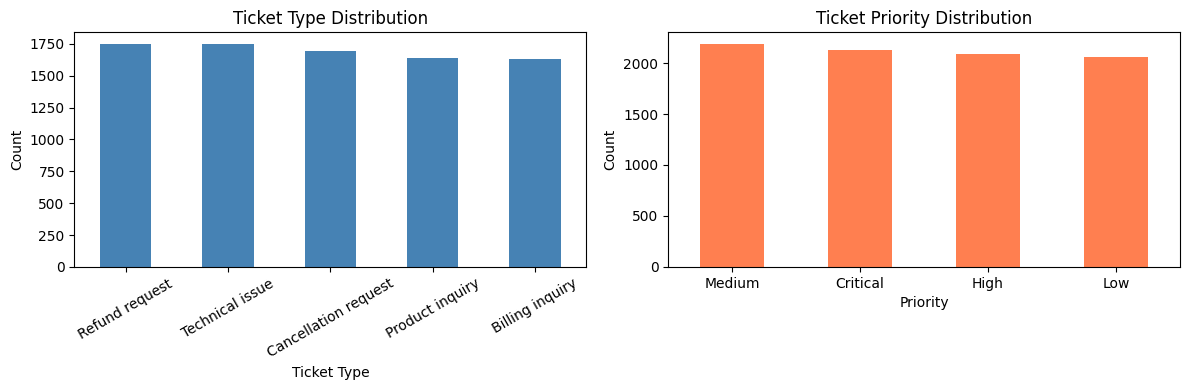

In [43]:

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df['Ticket Type'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Ticket Type Distribution')
plt.xlabel('Ticket Type')
plt.ylabel('Count')
plt.xticks(rotation=30)

plt.subplot(1, 2, 2)
df['Ticket Priority'].value_counts().plot(kind='bar', color='coral')
plt.title('Ticket Priority Distribution')
plt.xlabel('Priority')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [10]:
# Let's see a sample ticket description
print("Sample ticket description:")
print(df['Ticket Description'][0])
print("\nTicket Type:", df['Ticket Type'][0])
print("Ticket Priority:", df['Ticket Priority'][0])

Sample ticket description:
I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.

Ticket Type: Technical issue
Ticket Priority: Critical


In [44]:
# Initialize stemmer and stopwords
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove special characters, numbers, punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 3. Remove extra whitespace
    text = text.strip()

    # 4. Tokenize (split into words)
    words = text.split()

    # 5. Remove stopwords (words like 'the', 'is', 'a' that don't add meaning)
    words = [word for word in words if word not in stop_words]

    # 6. Stemming (reduce words to root form e.g. 'running' -> 'run')
    words = [stemmer.stem(word) for word in words]

    # 7. Join back into a string
    cleaned = ' '.join(words)

    return cleaned

print("Function defined!")
print("\nExample:")
sample = df['Ticket Description'][0]
print("BEFORE:", sample[:150])
print("\nAFTER:", clean_text(sample)[:150])

Function defined!

Example:
BEFORE: I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website ad

AFTER: im issu productpurchas pleas assist bill zip code appreci request websit address pleas doubl check email address ive tri troubleshoot step mention use


In [47]:
# Apply cleaning to all ticket descriptions
# This might take a minute...
print("Cleaning text... please wait...")

df['cleaned_text'] = df['Ticket Description'].apply(clean_text)

print("✅ Text cleaning done!")
print("\nSample cleaned text:")
print(df['cleaned_text'][0])

Cleaning text... please wait...
✅ Text cleaning done!

Sample cleaned text:
im issu productpurchas pleas assist bill zip code appreci request websit address pleas doubl check email address ive tri troubleshoot step mention user manual issu persist


In [48]:
# TF-IDF Vectorizer converts text into numerical features
# max_features=5000 means we only keep the top 5000 most important words

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
# ngram_range=(1,2) means we consider both single words AND pairs of words

X = tfidf.fit_transform(df['cleaned_text'])

print("Shape of feature matrix:", X.shape)
print(f"We have {X.shape[0]} tickets and {X.shape[1]} features (words/phrases)")

Shape of feature matrix: (8469, 5000)
We have 8469 tickets and 5000 features (words/phrases)


In [49]:
# Prepare labels for ticket type
y_type = df['Ticket Type']

print("Target classes:")
print(y_type.value_counts())

Target classes:
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_type,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 6775
Testing samples: 1694


In [16]:
# --- MODEL 1: Naive Bayes ---
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_predictions = nb_model.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_predictions)

print("Naive Bayes Accuracy:", round(nb_accuracy * 100, 2), "%")

Naive Bayes Accuracy: 19.01 %


In [17]:
# --- MODEL 2: Logistic Regression ---
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Logistic Regression Accuracy:", round(lr_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 19.42 %


In [18]:
# --- MODEL 3: Random Forest ---

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 19.6 %


In [19]:
# Compare all models for ticket type
print("========================================")
print("  MODEL COMPARISON — Ticket Type Task")
print("========================================")
print(f"Naive Bayes        : {round(nb_accuracy * 100, 2)}%")
print(f"Logistic Regression: {round(lr_accuracy * 100, 2)}%")
print(f"Random Forest      : {round(rf_accuracy * 100, 2)}%")

  MODEL COMPARISON — Ticket Type Task
Naive Bayes        : 19.01%
Logistic Regression: 19.42%
Random Forest      : 19.6%


In [20]:
print("Detailed Report — Logistic Regression (Ticket Type):")
print("="*60)
print(classification_report(y_test, lr_predictions))

Detailed Report — Logistic Regression (Ticket Type):
                      precision    recall  f1-score   support

     Billing inquiry       0.17      0.11      0.14       357
Cancellation request       0.20      0.22      0.21       327
     Product inquiry       0.20      0.22      0.21       316
      Refund request       0.18      0.19      0.18       345
     Technical issue       0.22      0.24      0.23       349

            accuracy                           0.19      1694
           macro avg       0.19      0.20      0.19      1694
        weighted avg       0.19      0.19      0.19      1694



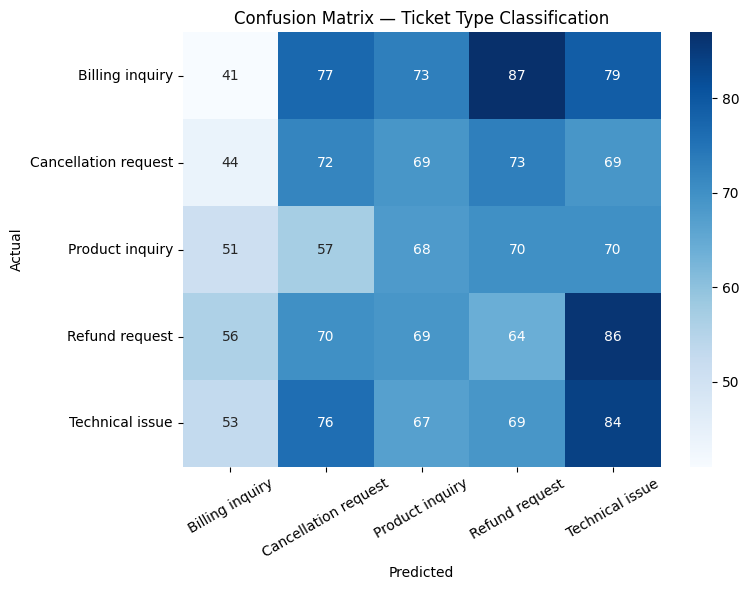


How to read this: Diagonal cells = correct predictions
Off-diagonal cells = mistakes the model made


In [21]:
# Confusion Matrix for Ticket Type
cm = confusion_matrix(y_test, lr_predictions)
labels = lr_model.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix — Ticket Type Classification')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("\nHow to read this: Diagonal cells = correct predictions")
print("Off-diagonal cells = mistakes the model made")

In [22]:
y_priority = df['Ticket Priority']

print("Priority classes:")
print(y_priority.value_counts())

Priority classes:
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64


In [23]:
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X, y_priority,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train_p.shape[0])
print("Testing samples:", X_test_p.shape[0])

Training samples: 6775
Testing samples: 1694


In [24]:

# Naive Bayes
nb_p = MultinomialNB()
nb_p.fit(X_train_p, y_train_p)
nb_p_acc = accuracy_score(y_test_p, nb_p.predict(X_test_p))

# Logistic Regression
lr_p = LogisticRegression(max_iter=1000, random_state=42)
lr_p.fit(X_train_p, y_train_p)
lr_p_acc = accuracy_score(y_test_p, lr_p.predict(X_test_p))

# Random Forest
rf_p = RandomForestClassifier(n_estimators=100, random_state=42)
rf_p.fit(X_train_p, y_train_p)
rf_p_acc = accuracy_score(y_test_p, rf_p.predict(X_test_p))

print("========================================")
print("  MODEL COMPARISON — Priority Task")
print("========================================")
print(f"Naive Bayes        : {round(nb_p_acc * 100, 2)}%")
print(f"Logistic Regression: {round(lr_p_acc * 100, 2)}%")
print(f"Random Forest      : {round(rf_p_acc * 100, 2)}%")

  MODEL COMPARISON — Priority Task
Naive Bayes        : 24.91%
Logistic Regression: 25.03%
Random Forest      : 24.5%


In [25]:

lr_p_preds = lr_p.predict(X_test_p)
print("Detailed Report — Logistic Regression (Priority):")
print("="*60)
print(classification_report(y_test_p, lr_p_preds))

Detailed Report — Logistic Regression (Priority):
              precision    recall  f1-score   support

    Critical       0.21      0.22      0.21       411
        High       0.27      0.27      0.27       409
         Low       0.24      0.26      0.25       415
      Medium       0.28      0.25      0.27       459

    accuracy                           0.25      1694
   macro avg       0.25      0.25      0.25      1694
weighted avg       0.25      0.25      0.25      1694



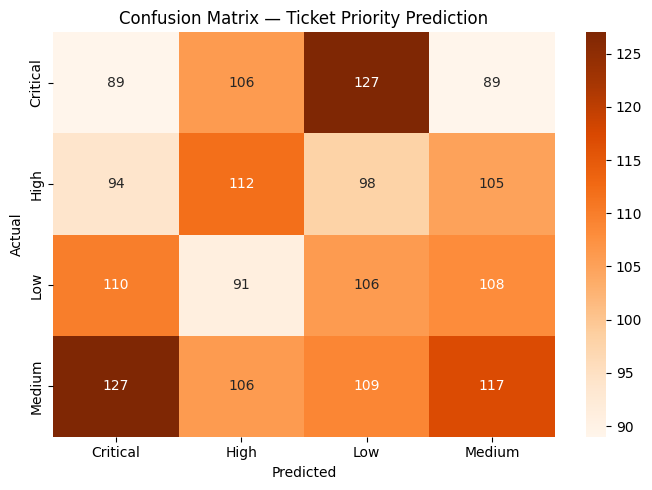

In [26]:
# Confusion Matrix for Priority
cm_p = confusion_matrix(y_test_p, lr_p_preds)
labels_p = lr_p.classes_

plt.figure(figsize=(7, 5))
sns.heatmap(cm_p, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels_p, yticklabels=labels_p)
plt.title('Confusion Matrix — Ticket Priority Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [27]:

results = {
    'Model': ['Naive Bayes', 'Logistic Regression', 'Random Forest'],
    'Ticket Type Accuracy (%)': [
        round(nb_accuracy * 100, 2),
        round(lr_accuracy * 100, 2),
        round(rf_accuracy * 100, 2)
    ],
    'Priority Accuracy (%)': [
        round(nb_p_acc * 100, 2),
        round(lr_p_acc * 100, 2),
        round(rf_p_acc * 100, 2)
    ]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Ticket Type Accuracy (%)  Priority Accuracy (%)
        Naive Bayes                     19.01                  24.91
Logistic Regression                     19.42                  25.03
      Random Forest                     19.60                  24.50


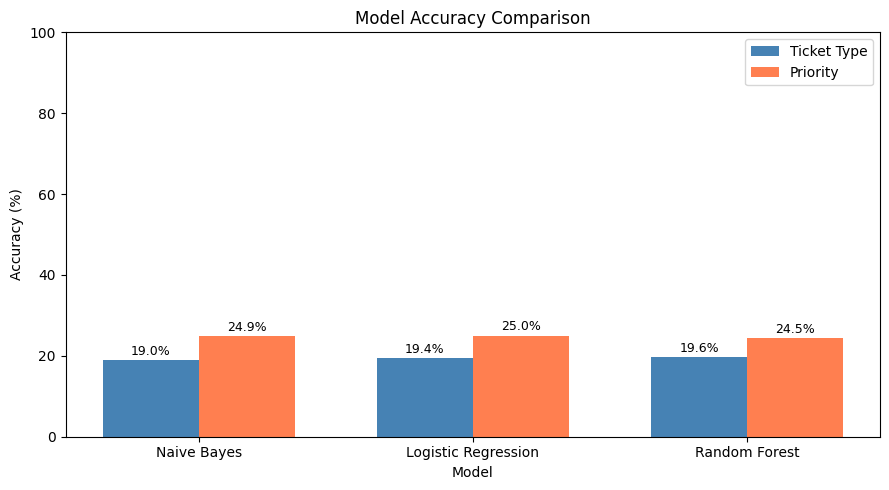

In [28]:

x = np.arange(3)
width = 0.35

type_accs = [nb_accuracy*100, lr_accuracy*100, rf_accuracy*100]
pri_accs  = [nb_p_acc*100,    lr_p_acc*100,    rf_p_acc*100]

plt.figure(figsize=(9, 5))
bars1 = plt.bar(x - width/2, type_accs, width, label='Ticket Type', color='steelblue')
bars2 = plt.bar(x + width/2, pri_accs,  width, label='Priority',    color='coral')

plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.xticks(x, ['Naive Bayes', 'Logistic Regression', 'Random Forest'])
plt.ylim(0, 100)
plt.legend()
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [37]:
def predict_ticket(description):
    """
    Takes a raw ticket description string,
    cleans it, and predicts both Type and Priority.
    """
    # Clean the input text
    cleaned = clean_text(description)

    # Convert to TF-IDF features
    features = tfidf.transform([cleaned])

    predicted_type = lr_model.predict(features)[0]
    type_confidence = max(lr_model.predict_proba(features)[0]) * 100
    predicted_priority = lr_p.predict(features)[0]
    priority_confidence = max(lr_p.predict_proba(features)[0]) * 100

    print("=" * 50)
    print("INPUT TICKET:")
    print(description)
    print("-" * 50)
    print(f"Predicted Type    : {predicted_type}  ({type_confidence:.1f}% confident)")
    print(f"Predicted Priority: {predicted_priority}  ({priority_confidence:.1f}% confident)")
    print("=" * 50)

predict_ticket("I was charged twice for my subscription last month and need a refund immediately!")

INPUT TICKET:
I was charged twice for my subscription last month and need a refund immediately!
--------------------------------------------------
Predicted Type    : Product inquiry  (30.7% confident)
Predicted Priority: Critical  (32.8% confident)


In [30]:
predict_ticket("My app keeps crashing every time I try to upload a photo. Please fix this bug.")

INPUT TICKET:
My app keeps crashing every time I try to upload a photo. Please fix this bug.
--------------------------------------------------
Predicted Type    : Product inquiry  (27.6% confident)
Predicted Priority: Critical  (33.6% confident)


In [31]:
predict_ticket("I want to cancel my monthly plan. Please guide me through the cancellation process.")

INPUT TICKET:
I want to cancel my monthly plan. Please guide me through the cancellation process.
--------------------------------------------------
Predicted Type    : Cancellation request  (33.4% confident)
Predicted Priority: Critical  (32.1% confident)


In [32]:
my_ticket = "I cannot login to my account since yesterday. It says password incorrect but I haven't changed it."
predict_ticket(my_ticket)

INPUT TICKET:
I cannot login to my account since yesterday. It says password incorrect but I haven't changed it.
--------------------------------------------------
Predicted Type    : Billing inquiry  (25.9% confident)
Predicted Priority: Medium  (30.8% confident)


In [33]:
from sklearn.metrics import classification_report
import json

report = classification_report(y_test, lr_predictions, output_dict=True)
report_df = pd.DataFrame(report).T
report_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'])
report_df = report_df[['precision', 'recall', 'f1-score', 'support']]

print("Per-Class Performance — Ticket Type:")
print(report_df.round(2))

Per-Class Performance — Ticket Type:
                      precision  recall  f1-score  support
Billing inquiry            0.17    0.11      0.14    357.0
Cancellation request       0.20    0.22      0.21    327.0
Product inquiry            0.20    0.22      0.21    316.0
Refund request             0.18    0.19      0.18    345.0
Technical issue            0.22    0.24      0.23    349.0


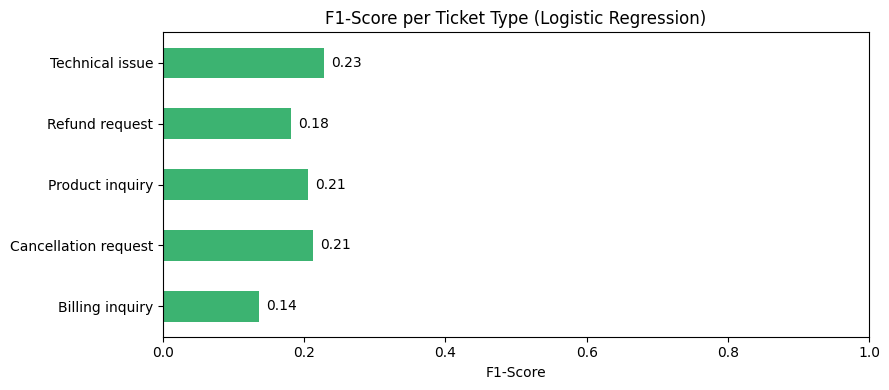

In [34]:
f1_scores = report_df['f1-score']

plt.figure(figsize=(9, 4))
f1_scores.plot(kind='barh', color='mediumseagreen')
plt.title('F1-Score per Ticket Type (Logistic Regression)')
plt.xlabel('F1-Score')
plt.xlim(0, 1)
for i, val in enumerate(f1_scores):
    plt.text(val + 0.01, i, f'{val:.2f}', va='center')
plt.tight_layout()
plt.show()